# As the classified data has subsetted genes; for complete gene counts - classification column added to original counts based on cell barcodes and checked for T cell markers expression

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 82408 × 4000
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scVI', 'X_totalvi_scarches', 'X_umap', 'protein_expression

In [12]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [3]:
adata_v4= sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/Malmberg_v4_fil_non10X_Datasetv2_PatientIDv2_nonNKremoval_adata_TcellFiltered.h5ad")

In [4]:
adata_v4

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [5]:
# Make sure both objects have aligned indices (i.e., same cell names)
common_cells = adata.obs_names.intersection(adata_v4.obs_names)

In [6]:
common_cells

Index(['AAACCTGAGTGTCCAT_1-0', 'AAACCTGCACATGGGA_1-0', 'AAACCTGCACCTCGGA_1-0',
       'AAACCTGGTTGAGTTC_1-0', 'AAACCTGTCACCGTAA_1-0', 'AAACCTGTCTCTTATG_1-0',
       'AAACGGGCACCAGCAC_1-0', 'AAACGGGCATGACGGA_1-0', 'AAAGATGCACGGACAA_1-0',
       'AAAGATGGTAGGGTAC_1-0',
       ...
       'rGBM-04-4_CACCAAAGTCACGCTG-1-0-1_abdelfattah_rGBM-04',
       'rGBM-04-4_CCTTCAGTCTAGAGCT-1-0-1_abdelfattah_rGBM-04',
       'rGBM-04-4_GACAGCCTCGAATCCA-1-0-1_abdelfattah_rGBM-04',
       'rGBM-04-4_GGTTAACGTGAGCAGT-1-0-1_abdelfattah_rGBM-04',
       'rGBM-04-4_GTGTTCCCAGAAGCGT-1-0-1_abdelfattah_rGBM-04',
       'rGBM-04-4_TAAGTCGGTTCTTGCC-1-0-1_abdelfattah_rGBM-04',
       'rGBM-05-2_ATATCCTAGTCATACC-1-0-1_abdelfattah_rGBM-05',
       'rGBM-05-2_CCCTCAACATAGACTC-1-0-1_abdelfattah_rGBM-05',
       'rGBM-05-3_AGGAAATCATTCATCT-1-0-1_abdelfattah_rGBM-05',
       'rGBM-05-3_TGACGCGGTGTCATTG-1-0-1_abdelfattah_rGBM-05'],
      dtype='object', length=82408)

In [7]:
#adata_v4
# Add the classification column from adata to adata_v4
adata_v4.obs.loc[common_cells, 'classification'] = adata.obs.loc[common_cells, 'classification']

In [8]:
adata_v4

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [10]:
#adata_v4.write_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [13]:
#adata_v4.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.csv")

In [11]:
adata_v4.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

Missing genes: []


/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/scanpy/plotting/_dotplot.py:761: RuntimeWarning: invalid value encountered in divide
  frac = (frac - dot_min) / old_range


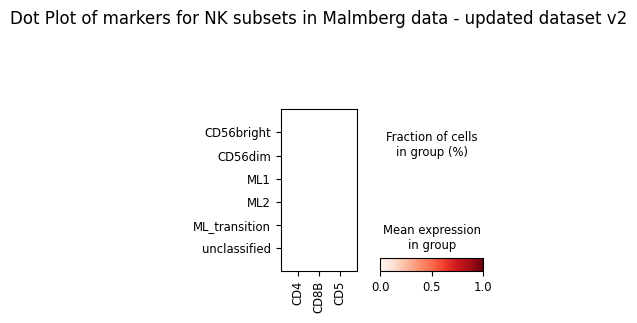

In [12]:
genes = ["CD4", "CD8B","CD5" ]

# Check for missing genes
missing_genes = [gene for gene in genes if gene not in adata_v4.var_names]
print("Missing genes:", missing_genes)

# Filter valid genes (those present in adata.var_names)
valid_genes = [gene for gene in genes if gene in adata_v4.var_names]

# Check if there are any valid genes to plot
if not valid_genes:
    raise ValueError("No valid genes to plot.")

# Subset the adata object to include only the valid genes
adata_valid = adata_v4[:, valid_genes]

# Scale the expression data for the valid genes (standardizing by z-score)
sc.pp.scale(adata_valid, zero_center=True, max_value=None)

# Generate a combined dot plot for all categories of 'classification'
sc.pl.dotplot(adata_valid, var_names=valid_genes, groupby='classification', 
              cmap='Reds', title='Dot Plot of markers for NK subsets in Malmberg data - updated dataset v2', vmax=1)

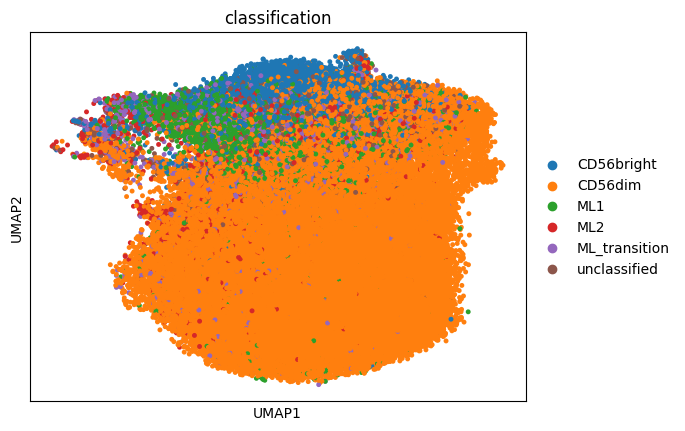

In [13]:
sc.pl.umap(adata_valid, color="classification",
           cmap='GnBu', ncols=4, 
           show=False, size=50)

plt.show()

In [14]:
# Convert the expression matrix to a DataFrame (dense if sparse)
if hasattr(adata_valid.X, "toarray"):  # If sparse matrix
    expr_matrix = adata_valid.X.toarray()
else:
    expr_matrix = adata_valid.X

expr_df = pd.DataFrame(expr_matrix, columns=valid_genes, index=adata_valid.obs_names)

# Binary expression: 1 if expressed (>0), 0 if not
expr_binary = (expr_df > 0).astype(int)

# Calculate % of cells expressing each gene per 'classification'
percent_expr = expr_binary.groupby(adata_valid.obs['classification']).mean() * 100

print("Percentage of cells expressing each gene per classification:\n")
print(percent_expr)


Percentage of cells expressing each gene per classification:

                CD4  CD8B  CD5
classification                
CD56bright      0.0   0.0  0.0
CD56dim         0.0   0.0  0.0
ML1             0.0   0.0  0.0
ML2             0.0   0.0  0.0
ML_transition   0.0   0.0  0.0
unclassified    0.0   0.0  0.0


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_71815/2766643409.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_expr = expr_binary.groupby(adata_valid.obs['classification']).mean() * 100


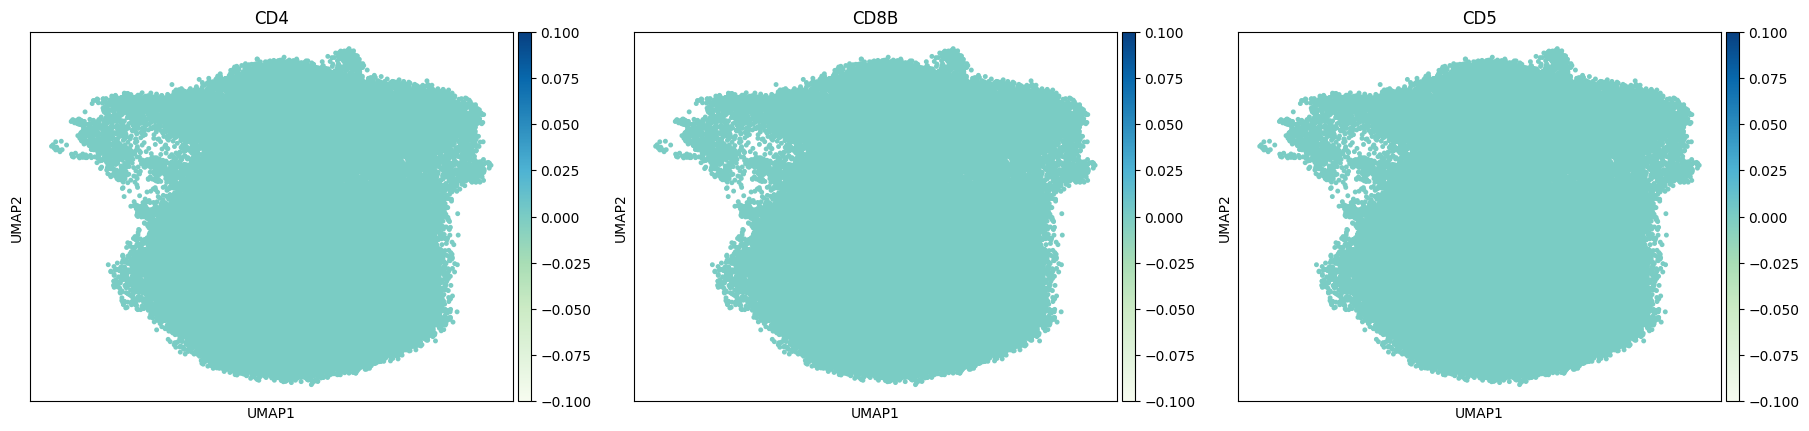

In [15]:
sc.pl.umap(adata_valid, color=valid_genes,
           cmap='GnBu', ncols=4, 
           show=False, size=50)

plt.show()

In [17]:
adata_v4.obs.groupby("source")["patient_ID_v2"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_71815/1948316186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_v4.obs.groupby("source")["patient_ID_v2"].nunique()


source
PBMC               12
breast_normal       6
breast_tumor       83
glioblastoma       98
lung_normal        66
lung_tumor         93
melanoma            8
pancreas_normal     9
pancreas_tumor     40
prostate_normal    10
prostate_tumor     23
sarcoma            18
skin_normal        23
Name: patient_ID_v2, dtype: int64